# NAIVE BAYES
## ¿Qué prioridad probablemente tendrá una llamada al 911?

**¿POR QUÉ NAIVE BAYES?**

Naive Bayes funciona muy bien con variables **CATEGÓRICAS** como las de este ejercicio (tipo de incidente, turno, zona, etc.). El método asume que, dado el valor de la variable objetivo, todas las variables predictoras son **INDEPENDIENTES** entre sí ("naive" = ingenuo, porque en la práctica rara vez son 100% independientes).

**La secuencia es:**
1. Cargar y limpiar los datos
2. Separar en entrenamiento (80%) y prueba (20%)
3. Entrenar el modelo Naive Bayes
4. Predecir sobre los datos de prueba
5. Construir matriz de confusión y evaluar el modelo
6. Revisar las probabilidades que aprendió el modelo


## PASO 0. Importar las librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB        # Naive Bayes para variables categóricas
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

%matplotlib inline

## PASO 1. Cargar la base de datos

**Nota:** ajusta la ruta del archivo CSV a donde tengas guardada tu base de datos en tu computadora.

In [2]:
datos = pd.read_csv(r"datos\base_911_prioridad.csv")

# Revisamos las primeras filas para confirmar que cargó bien
datos.head()

,tipo_incidente,turno,dia_semana,zona,quien_reporta,arma_mencionada,prioridad
0,Robo_con_violencia,Matutino,Entre_semana,Via_publica,Vecino,Si,Alta
1,Persona_sospechosa,Vespertino,Fin_de_semana,Via_publica,Vecino,Si,Alta
2,Accidente_vial,Vespertino,Fin_de_semana,Via_publica,Vecino,No,Media
3,Persona_sospechosa,Nocturno,Entre_semana,Habitacional,Anonimo,No,Baja
4,Auto_sospechoso,Matutino,Entre_semana,Comercial,Anonimo,No,Baja


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   tipo_incidente   1000 non-null   object
 1   turno            1000 non-null   object
 2   dia_semana       1000 non-null   object
 3   zona             1000 non-null   object
 4   quien_reporta    1000 non-null   object
 5   arma_mencionada  1000 non-null   object
 6   prioridad        1000 non-null   object
dtypes: object(7)
memory usage: 54.8+ KB


In [4]:
# ¿Cuántas llamadas hay de cada prioridad?
datos["prioridad"].value_counts()

prioridad
Baja     433
Alta     348
Media    219
Name: count, dtype: int64

## PASO 2. Preparar las variables (X) y la variable objetivo (y)

**IMPORTANTE:** a diferencia del árbol y Random Forest (donde usamos `pd.get_dummies` para crear columnas 0/1), aquí usamos `OrdinalEncoder`. `CategoricalNB` de scikit-learn espera que cada variable categórica esté codificada como un solo número entero (0, 1, 2, 3...) por categoría, NO como columnas dummy separadas.

### 2a. Variable objetivo (y)

In [5]:
# "prioridad" tiene los valores "Alta" / "Media" / "Baja".
le_objetivo = LabelEncoder()
y = le_objetivo.fit_transform(datos["prioridad"])
print("\nCategorías de la variable objetivo y su código numérico:")
dict(zip(le_objetivo.classes_, le_objetivo.transform(le_objetivo.classes_)))


Categorías de la variable objetivo y su código numérico:


{'Alta': np.int64(0), 'Baja': np.int64(1), 'Media': np.int64(2)}

### 2b. Variables predictoras (X)

In [6]:
# Todas nuestras variables predictoras son categóricas (texto), así que
# las codificamos TODAS con OrdinalEncoder (un número por categoría).
X_texto = datos.drop(columns=["prioridad"])  # quito la variable a predecir
encoder_X = OrdinalEncoder()
X = encoder_X.fit_transform(X_texto)
# Convertimos a DataFrame de nuevo solo para que sea más fácil de leer
X = pd.DataFrame(X, columns=X_texto.columns)

# Variables predictoras después de codificar (primeras filas):
X.head()

,tipo_incidente,turno,dia_semana,zona,quien_reporta,arma_mencionada
0,5.0,0.0,0.0,3.0,2.0,1.0
1,4.0,2.0,1.0,3.0,2.0,1.0
2,0.0,2.0,1.0,3.0,2.0,0.0
3,4.0,1.0,0.0,2.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Diccionario para poder traducir los códigos numéricos de vuelta a
# categorías originales más adelante (nos sirve para interpretar el modelo)
categorias_por_variable = {
    col: list(encoder_X.categories_[i])
    for i, col in enumerate(X_texto.columns)
}
categorias_por_variable

{'tipo_incidente': ['Accidente_vial',
  'Auto_sospechoso',
  'Disturbio_vecinal',
  'Incendio',
  'Persona_sospechosa',
  'Robo_con_violencia',
  'Robo_sin_violencia',
  'Violencia_familiar'],
 'turno': ['Matutino', 'Nocturno', 'Vespertino'],
 'dia_semana': ['Entre_semana', 'Fin_de_semana'],
 'zona': ['Comercial', 'Escolar', 'Habitacional', 'Via_publica'],
 'quien_reporta': ['Anonimo', 'Testigo', 'Vecino', 'Victima'],
 'arma_mencionada': ['No', 'Si']}

## PASO 3. Dividir en entrenamiento (80%) y prueba (20%)

Mantiene la misma proporción de Alta/Media/Baja en ambos conjuntos con el argumento `stratify`.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% para prueba
    random_state=123,    # semilla, ahora probemos con 123
    stratify=y            # mantiene la proporción de prioridad en ambos sets
)
print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]} llamadas")
print(f"Tamaño del conjunto de prueba:        {X_test.shape[0]} llamadas")


Tamaño del conjunto de entrenamiento: 800 llamadas
Tamaño del conjunto de prueba:        200 llamadas


## PASO 4. Crear y entrenar el modelo Naive Bayes

In [9]:
modelo_nb = CategoricalNB()

# Entrenamos el modelo con los datos de entrenamiento
modelo_nb.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


## PASO 5. Revisar las probabilidades que aprendió el modelo

### 5a. Probabilidades A PRIORI (antes de ver ninguna variable)

Esto es, simplemente, qué proporción de llamadas de entrenamiento fueron Alta / Media / Baja.

In [10]:
print("\n" + "="*60)
print("PROBABILIDADES A PRIORI (P de cada clase, antes de cualquier dato)")
print("="*60)
prob_priori = np.exp(modelo_nb.class_log_prior_)
for clase, prob in zip(le_objetivo.classes_, prob_priori):
    print(f"  P({clase}) = {prob:.3f}")


PROBABILIDADES A PRIORI (P de cada clase, antes de cualquier dato)
  P(Alta) = 0.348
  P(Baja) = 0.434
  P(Media) = 0.219


### 5b. Probabilidades CONDICIONALES por variable

Para cada variable predictora, ¿qué tan probable es cada una de sus categorías, DADO que la llamada es de prioridad Alta / Media / Baja? Esto es el corazón de Naive Bayes: aprender estas probabilidades para cada variable, asumiendo que son independientes entre sí.

In [11]:
print("\n" + "="*60)
print("PROBABILIDADES CONDICIONALES (ejemplo: tipo_incidente)")
print("="*60)
idx_var = list(X.columns).index("tipo_incidente")
tabla_prob = np.exp(modelo_nb.feature_log_prob_[idx_var])
nombres_categorias = categorias_por_variable["tipo_incidente"]
tabla_prob_df = pd.DataFrame(
    tabla_prob.T,  # transponemos para que las categorías queden en filas
    index=nombres_categorias,
    columns=le_objetivo.classes_
)
tabla_prob_df.round(2)


PROBABILIDADES CONDICIONALES (ejemplo: tipo_incidente)


,Alta,Baja,Media
Accidente_vial,0.07,0.00,0.50
Auto_sospechoso,0.00,0.34,0.01
Disturbio_vecinal,0.03,0.25,0.17
Incendio,0.16,0.00,0.01
Persona_sospechosa,0.08,0.10,0.24
Robo_con_violencia,0.36,0.00,0.01
Robo_sin_violencia,0.00,0.30,0.07
Violencia_familiar,0.29,0.00,0.01


**Lectura:** cada celda es P(categoría | prioridad). Por ejemplo, la fila "Robo_con_violencia" muestra qué tan probable es ese tipo de incidente dentro de cada nivel de prioridad. Si esa probabilidad es mucho más alta en la columna "Alta" que en las demás, el modelo "aprende" que ver un robo con violencia es una señal fuerte de llamada urgente.

## PASO 6. Predecir sobre el conjunto de prueba

In [12]:
predicciones = modelo_nb.predict(X_test)

# También podemos ver las probabilidades por clase para cada predicción,
# muy útil en la práctica para saber qué tan "seguro" está el modelo
probabilidades = modelo_nb.predict_proba(X_test)
print("\nPrimeras 5 predicciones (con su probabilidad por clase):")
for i in range(5):
    clase_predicha = le_objetivo.classes_[predicciones[i]]
    probs_texto = ", ".join(
        f"{cl}={p:.2f}" for cl, p in zip(le_objetivo.classes_, probabilidades[i])
    )
    print(f"  Llamada {i+1}: predicción = {clase_predicha}  |  probabilidades: {probs_texto}")


Primeras 5 predicciones (con su probabilidad por clase):
  Llamada 1: predicción = Baja  |  probabilidades: Alta=0.10, Baja=0.53, Media=0.37
  Llamada 2: predicción = Alta  |  probabilidades: Alta=0.94, Baja=0.02, Media=0.03
  Llamada 3: predicción = Baja  |  probabilidades: Alta=0.00, Baja=0.97, Media=0.02
  Llamada 4: predicción = Media  |  probabilidades: Alta=0.12, Baja=0.02, Media=0.86
  Llamada 5: predicción = Baja  |  probabilidades: Alta=0.01, Baja=0.98, Media=0.01


## PASO 7. Matriz de confusión y métricas de evaluación

In [13]:
print("\n" + "="*60)
print("MATRIZ DE CONFUSIÓN — Naive Bayes")
print("="*60)
matriz = confusion_matrix(y_test, predicciones)
matriz_df = pd.DataFrame(matriz, index=le_objetivo.classes_, columns=le_objetivo.classes_)
print("(filas = realidad, columnas = predicción)")
print(matriz_df)


MATRIZ DE CONFUSIÓN — Naive Bayes
(filas = realidad, columnas = predicción)
       Alta  Baja  Media
Alta     62     0      8
Baja      0    83      3
Media     2    10     32


In [14]:
exactitud = accuracy_score(y_test, predicciones)
print(f"\nExactitud general del modelo (accuracy): {exactitud:.3f}")
print("\nReporte de clasificación completo:")
print(classification_report(y_test, predicciones, target_names=le_objetivo.classes_))


Exactitud general del modelo (accuracy): 0.885

Reporte de clasificación completo:
              precision    recall  f1-score   support

        Alta       0.97      0.89      0.93        70
        Baja       0.89      0.97      0.93        86
       Media       0.74      0.73      0.74        44

    accuracy                           0.89       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.89      0.89      0.88       200



**INTERPRETACIÓN PARA OPERACIÓN DE EMERGENCIAS:**

- Recuerda: el modelo predice la prioridad ANTES de que una patrulla confirme en campo qué tan grave era el caso. Por eso su valor está en ayudar a decidir el despacho con anticipación, a partir no solo del hecho reportado, sino de las otras variables que tienen un rol.

## PASO 8. Visualizar la matriz de confusión

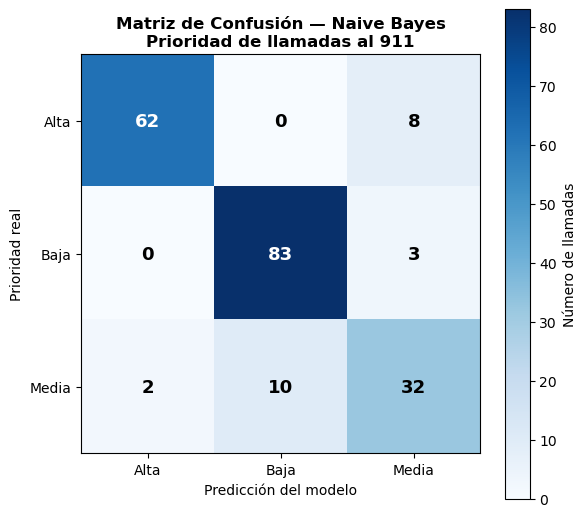

In [15]:
fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(matriz, cmap="Blues")
ax.set_xticks(range(len(le_objetivo.classes_)))
ax.set_yticks(range(len(le_objetivo.classes_)))
ax.set_xticklabels(le_objetivo.classes_)
ax.set_yticklabels(le_objetivo.classes_)
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Prioridad real")
ax.set_title("Matriz de Confusión — Naive Bayes\nPrioridad de llamadas al 911",
              fontsize=12, fontweight="bold")
# Agregamos el número dentro de cada celda
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        color_texto = "white" if matriz[i, j] > matriz.max()/2 else "black"
        ax.text(j, i, str(matriz[i, j]), ha="center", va="center",
                color=color_texto, fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, label="Número de llamadas")
plt.tight_layout()
plt.show()